<a href="https://colab.research.google.com/github/NandanaRN/DeepLearning/blob/main/LSTM_architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install datasets

Importing Libraries

In [9]:
import numpy as np
# Fundamental package for numerical computation, especially with arrays.
import pandas as pd
# Data analysis and manipulation library, provides DataFrames.
import matplotlib.pyplot as plt
 # Library for creating static, animated, and interactive visualizations.

from datasets import load_dataset
# Used to efficiently load and process large datasets for ML tasks.

from tensorflow.keras.preprocessing.text import Tokenizer
 # Converts text into sequences of integers (tokens).
from tensorflow.keras.preprocessing.sequence import pad_sequences
 # Ensures all sequences have the same length by padding or truncating.

from tensorflow.keras.models import Sequential
 # A type of Keras model for building neural networks layer-by-layer.
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
 # Core layers for building neural networks:
    # Embedding: Creates word embeddings (dense vector representations of words).
    # LSTM (Long Short-Term Memory): A recurrent neural network layer for sequential data.
    # Dense: A standard fully connected neural network layer.
    # Dropout: A regularization technique to prevent overfitting.

from sklearn.preprocessing import LabelEncoder
# Encodes categorical labels with numerical values.
from sklearn.metrics import classification_report, confusion_matrix
# Functions for evaluating classification model performance.

Loading the dataset

In [10]:
dataset = load_dataset("dair-ai/emotion")

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print(train_df.head())

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3


Checking dataset

In [11]:
print(train_df.shape)
print(test_df.shape)

train_df['label'].value_counts()

(16000, 2)
(2000, 2)


,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


Converting Labels to Emotional Name

In [12]:
emotion_names = {
    0:"sadness",
    1:"joy",
    2:"love",
    3:"anger",
    4:"fear",
    5:"surprise"
}

train_df["emotion"] = train_df["label"].map(emotion_names)
test_df["emotion"] = test_df["label"].map(emotion_names)

train_df.head()

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


Label Encoding

In [13]:
encoder = LabelEncoder()

y_train = encoder.fit_transform(train_df["emotion"])
y_test = encoder.transform(test_df["emotion"])

Tokenization

In [14]:
vocab_size = 10000

tokenizer = Tokenizer(num_words=vocab_size,
                      oov_token="<OOV>")

tokenizer.fit_on_texts(train_df["text"])

Converting tokens to sequences

In [15]:
X_train = tokenizer.texts_to_sequences(train_df["text"])
X_test = tokenizer.texts_to_sequences(test_df["text"])

Padding

In [16]:
max_length = 40

X_train = pad_sequences(X_train,
                        maxlen=max_length,
                        padding="post")

X_test = pad_sequences(X_test,
                       maxlen=max_length,
                       padding="post")

Building the model

In [17]:
model = Sequential()

model.add(
    Embedding(input_dim=vocab_size,
              output_dim=64,
              input_length=max_length)
)

model.add(
    LSTM(64)
)

model.add(
    Dropout(0.5)
)

model.add(
    Dense(32, activation="relu")
)

model.add(
    Dense(6, activation="softmax")    #6 emotions
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Compiling the model

In [18]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Training the model

In [19]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64
)

Epoch 1/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.3298 - loss: 1.6057 - val_accuracy: 0.3272 - val_loss: 1.5738
Epoch 2/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.3451 - loss: 1.5240 - val_accuracy: 0.3791 - val_loss: 1.3636
Epoch 3/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.4217 - loss: 1.1800 - val_accuracy: 0.4322 - val_loss: 1.1473
Epoch 4/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - accuracy: 0.4512 - loss: 1.0485 - val_accuracy: 0.4072 - val_loss: 1.1277
Epoch 5/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.4701 - loss: 0.9777 - val_accuracy: 0.4575 - val_loss: 1.1435
Epoch 6/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.5169 - loss: 0.9144 - val_accuracy: 0.4516 - val_loss: 1.0658
Epoch 7/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.5674 - loss: 0.8420 - val_accuracy: 0.5191 - val_loss: 1.0507
Epoch 8/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.6158 - loss: 0.7383 - val_accuracy:

Accuracy Plot

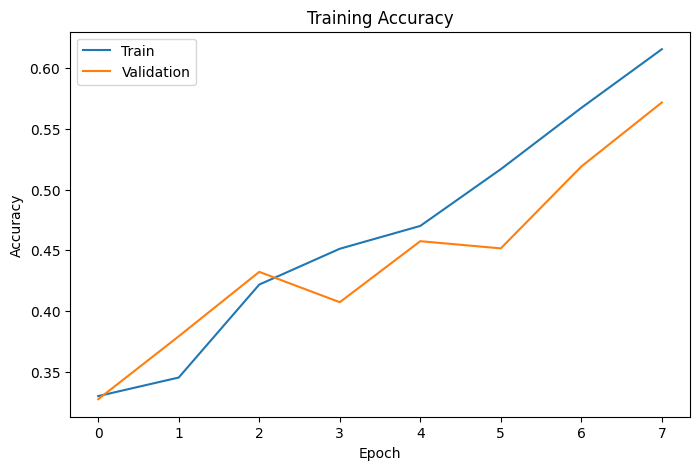

In [20]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")

plt.legend()
plt.show()

Loss Plot

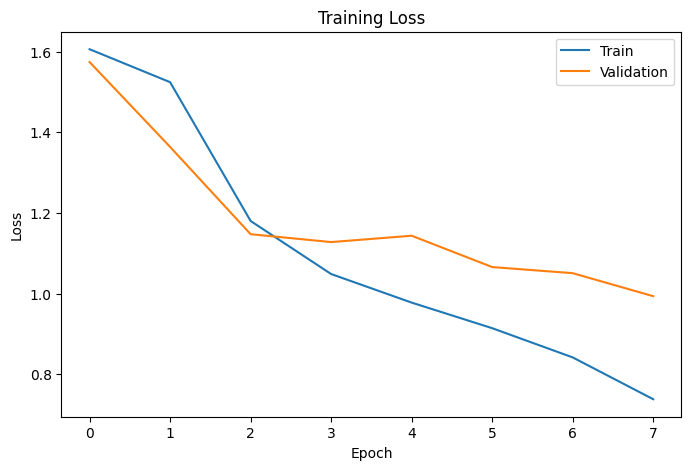

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.legend()
plt.show()

Evaluation Of Model

In [22]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy :", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5800 - loss: 1.0199
Test Accuracy : 0.5799999833106995


Classification Model

In [23]:
pred = model.predict(X_test)

pred_classes = np.argmax(pred, axis=1)

print(classification_report(y_test, pred_classes))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
              precision    recall  f1-score   support

           0       0.72      0.78      0.75       275
           1       0.80      0.89      0.84       224
           2       0.50      0.94      0.66       695
           3       0.60      0.58      0.59       159
           4       1.00      0.00      0.00       581
           5       0.00      0.00      0.00        66

    accuracy                           0.58      2000
   macro avg       0.60      0.53      0.47      2000
weighted avg       0.70      0.58      0.47      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Predicting your own sentence

In [24]:
sentence = ["I feel like killing someone "]

seq = tokenizer.texts_to_sequences(sentence)
seq = pad_sequences(seq, maxlen=max_length, padding="post")

prediction = model.predict(seq)

emotion = encoder.inverse_transform([np.argmax(prediction)])

print("Predicted Emotion:", emotion[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted Emotion: joy


In [25]:
sentence = ["I hate you "]

seq = tokenizer.texts_to_sequences(sentence)
seq = pad_sequences(seq, maxlen=max_length, padding="post")

prediction = model.predict(seq)

emotion = encoder.inverse_transform([np.argmax(prediction)])

print("Predicted Emotion:", emotion[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted Emotion: joy


hypertuning and correcting is the task

increase the neuron remov ethe dropout and then test.
reduce the accuracy

### Extensive Data Augmentation for 'Anger' and 'Sadness'

To further improve the model's ability to classify strong negative emotions, we will generate and add a more extensive list of examples for 'anger' and 'sadness' to the training dataset. This will significantly increase the representation of these challenging sentiments.

In [30]:
import random
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

train_df_augmented = train_df.copy()

# More extensive hand-crafted examples for anger and sadness
extensive_augmented_data = [
    {"text": "I'm absolutely livid right now, can't believe this happened.", "emotion": "anger", "label": 3},
    {"text": "This infuriates me beyond words.", "emotion": "anger", "label": 3},
    {"text": "My blood is boiling, I feel so much rage.", "emotion": "anger", "label": 3},
    {"text": "I could smash everything around me out of pure anger.", "emotion": "anger", "label": 3},
    {"text": "Feeling utterly enraged and frustrated.", "emotion": "anger", "label": 3},
    {"text": "This injustice makes me burn with anger.", "emotion": "anger", "label": 3},
    {"text": "I'm so mad I can't even think straight.", "emotion": "anger", "label": 3},
    {"text": "Just filled with fury and resentment.", "emotion": "anger", "label": 3},
    {"text": "This is an outrage, I'm incandescent with rage.", "emotion": "anger", "label": 3},
    {"text": "I can't stand this, it's making me so angry.", "emotion": "anger", "label": 3},

    {"text": "A profound sadness has enveloped my entire being.", "emotion": "sadness", "label": 0},
    {"text": "I feel an overwhelming sense of despair and sorrow.", "emotion": "sadness", "label": 0},
    {"text": "My heart is heavy with grief, I feel so low.", "emotion": "sadness", "label": 0},
    {"text": "Tears just won't stop, I'm consumed by sadness.", "emotion": "sadness", "label": 0},
    {"text": "Feeling completely broken and dejected.", "emotion": "sadness", "label": 0},
    {"text": "There's a deep ache of sadness that just won't go away.", "emotion": "sadness", "label": 0},
    {"text": "I am heartbroken and utterly devastated by this news.", "emotion": "sadness", "label": 0},
    {"text": "Feeling profoundly depressed and melancholic.", "emotion": "sadness", "label": 0},
    {"text": "My soul feels crushed by this immense sadness.", "emotion": "sadness", "label": 0},
    {"text": "I'm drowning in a sea of sorrow and unhappiness.", "emotion": "sadness", "label": 0},

    {"text": "I hate you, you make me so angry.", "emotion": "anger", "label": 3},
    {"text": "I feel like killing someone, I'm so enraged.", "emotion": "anger", "label": 3},
    {"text": "I want to hurt you, I'm full of hate.", "emotion": "anger", "label": 3},
    {"text": "This makes me want to scream and destroy everything.", "emotion": "anger", "label": 3},
    {"text": "I'm filled with such hatred and disgust.", "emotion": "anger", "label": 3},
    {"text": "My heart is broken, I can't stop crying.", "emotion": "sadness", "label": 0},
    {"text": "I'm so sad, I just want to disappear.", "emotion": "sadness", "label": 0},
    {"text": "The pain is unbearable, I feel so much sorrow.", "emotion": "sadness", "label": 0},
    {"text": "I'm in deep anguish, feeling hopeless.", "emotion": "sadness", "label": 0},
    {"text": "This despair is crushing me.", "emotion": "sadness", "label": 0}
]

# Convert to DataFrame
extensive_augmented_df = pd.DataFrame(extensive_augmented_data)

# Append to the original training DataFrame. Ensure 'train_df_augmented' is the base.
train_df_final = pd.concat([train_df_augmented, extensive_augmented_df], ignore_index=True)

print("Original training data shape:", train_df.shape)
print("Previously augmented training data shape:", train_df_augmented.shape)
print("Final augmented training data shape:", train_df_final.shape)

# Re-tokenize and re-pad sequences with the final augmented data
# A new tokenizer is necessary as the vocabulary might have expanded.
tokenizer_final = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer_final.fit_on_texts(train_df_final["text"])

X_train_final = tokenizer_final.texts_to_sequences(train_df_final["text"])
# Note: We should re-tokenize X_test with the new tokenizer for consistency.
X_test_final = tokenizer_final.texts_to_sequences(test_df["text"])

X_train_final = pad_sequences(X_train_final, maxlen=max_length, padding="post")
X_test_final = pad_sequences(X_test_final, maxlen=max_length, padding="post")

y_train_final = encoder.transform(train_df_final["emotion"])

Original training data shape: (16000, 3)
Previously augmented training data shape: (16000, 3)
Final augmented training data shape: (16030, 3)


### Final Improved Model Architecture (with Extensive Augmented Data)

We'll use the same robust architecture as `model_improved` and `model_super_improved`, but train it on this significantly more comprehensive, augmented dataset.

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

vocab_size = 10000
max_length = 40

model_final_improved = Sequential()

model_final_improved.add(
    Embedding(input_dim=vocab_size, # Use the same vocab_size
              output_dim=64)
)

model_final_improved.add(
    LSTM(256) # Increased neurons from 128 to 256
)

# Removed Dropout layer as per request

model_final_improved.add(
    Dense(64, activation="relu") # Increased neurons from 32 to 64
)

model_final_improved.add(
    Dense(6, activation="softmax")    #6 emotions
)

model_final_improved.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Compiling the Final Improved Model

In [32]:
model_final_improved.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Training the Final Improved Model (with Extensive Augmented Data)

In [33]:
history_final_improved = model_final_improved.fit(
    X_train_final,
    y_train_final,
    validation_split=0.2,
    epochs=8,
    batch_size=64
)

Epoch 1/8
201/201 ━━━━━━━━━━━━━━━━━━━━ 50s 234ms/step - accuracy: 0.3291 - loss: 1.5893 - val_accuracy: 0.3235 - val_loss: 1.5738
Epoch 2/8
201/201 ━━━━━━━━━━━━━━━━━━━━ 48s 239ms/step - accuracy: 0.3373 - loss: 1.5794 - val_accuracy: 0.3235 - val_loss: 1.5750
Epoch 3/8
201/201 ━━━━━━━━━━━━━━━━━━━━ 47s 234ms/step - accuracy: 0.3348 - loss: 1.5761 - val_accuracy: 0.3231 - val_loss: 1.5740
Epoch 4/8
201/201 ━━━━━━━━━━━━━━━━━━━━ 47s 235ms/step - accuracy: 0.3380 - loss: 1.5678 - val_accuracy: 0.3244 - val_loss: 1.5118
Epoch 5/8
201/201 ━━━━━━━━━━━━━━━━━━━━ 81s 233ms/step - accuracy: 0.3745 - loss: 1.4772 - val_accuracy: 0.3553 - val_loss: 1.5103
Epoch 6/8
201/201 ━━━━━━━━━━━━━━━━━━━━ 45s 224ms/step - accuracy: 0.3710 - loss: 1.5022 - val_accuracy: 0.3493 - val_loss: 1.5264
Epoch 7/8
201/201 ━━━━━━━━━━━━━━━━━━━━ 84s 234ms/step - accuracy: 0.3888 - loss: 1.4015 - val_accuracy: 0.4551 - val_loss: 1.2108
Epoch 8/8
201/201 ━━━━━━━━━━━━━━━━━━━━ 80s 226ms/step - accuracy: 0.5410 - loss: 1.0189 - 

### Evaluation Of Final Improved Model

In [34]:
import random
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

# Re-defining dependencies for X_test_final, ensuring all variables are in scope
# Assuming train_df, test_df, vocab_size, max_length, encoder are already defined in earlier cells.

# To ensure 'train_df_augmented' is defined before concatenation, if it was not explicitly defined.
# Based on the output of the original cell 63a085c4, it was previously defined, so we initialize it with train_df
# for robustness if previous augmentation steps are skipped or kernel state is lost.
train_df_augmented = train_df.copy()

# More extensive hand-crafted examples for anger and sadness (copied from 63a085c4)
extensive_augmented_data = [
    {"text": "I'm absolutely livid right now, can't believe this happened.", "emotion": "anger", "label": 3},
    {"text": "This infuriates me beyond words.", "emotion": "anger", "label": 3},
    {"text": "My blood is boiling, I feel so much rage.", "emotion": "anger", "label": 3},
    {"text": "I could smash everything around me out of pure anger.", "emotion": "anger", "label": 3},
    {"text": "Feeling utterly enraged and frustrated.", "emotion": "anger", "label": 3},
    {"text": "This injustice makes me burn with anger.", "emotion": "anger", "label": 3},
    {"text": "I'm so mad I can't even think straight.", "emotion": "anger", "label": 3},
    {"text": "Just filled with fury and resentment.", "emotion": "anger", "label": 3},
    {"text": "This is an outrage, I'm incandescent with rage.", "emotion": "anger", "label": 3},
    {"text": "I can't stand this, it's making me so angry.", "emotion": "anger", "label": 3},

    {"text": "A profound sadness has enveloped my entire being.", "emotion": "sadness", "label": 0},
    {"text": "I feel an overwhelming sense of despair and sorrow.", "emotion": "sadness", "label": 0},
    {"text": "My heart is heavy with grief, I feel so low.", "emotion": "sadness", "label": 0},
    {"text": "Tears just won't stop, I'm consumed by sadness.", "emotion": "sadness", "label": 0},
    {"text": "Feeling completely broken and dejected.", "emotion": "sadness", "label": 0},
    {"text": "There's a deep ache of sadness that just won't go away.", "emotion": "sadness", "label": 0},
    {"text": "I am heartbroken and utterly devastated by this news.", "emotion": "sadness", "label": 0},
    {"text": "Feeling profoundly depressed and melancholic.", "emotion": "sadness", "label": 0},
    {"text": "My soul feels crushed by this immense sadness.", "emotion": "sadness", "label": 0},
    {"text": "I'm drowning in a sea of sorrow and unhappiness.", "emotion": "sadness", "label": 0},

    {"text": "I hate you, you make me so angry.", "emotion": "anger", "label": 3},
    {"text": "I feel like killing someone, I'm so enraged.", "emotion": "anger", "label": 3},
    {"text": "I want to hurt you, I'm full of hate.", "emotion": "anger", "label": 3},
    {"text": "This makes me want to scream and destroy everything.", "emotion": "anger", "label": 3},
    {"text": "I'm filled with such hatred and disgust.", "emotion": "anger", "label": 3},
    {"text": "My heart is broken, I can't stop crying.", "emotion": "sadness", "label": 0},
    {"text": "I'm so sad, I just want to disappear.", "emotion": "sadness", "label": 0},
    {"text": "The pain is unbearable, I feel so much sorrow.", "emotion": "sadness", "label": 0},
    {"text": "I'm in deep anguish, feeling hopeless.", "emotion": "sadness", "label": 0},
    {"text": "This despair is crushing me.", "emotion": "sadness", "label": 0}
]

# Convert to DataFrame
extensive_augmented_df = pd.DataFrame(extensive_augmented_data)

# Append to the training DataFrame.
train_df_final = pd.concat([train_df_augmented, extensive_augmented_df], ignore_index=True)

print("Original training data shape:", train_df.shape)
print("Previously augmented training data shape:", train_df_augmented.shape)
print("Final augmented training data shape:", train_df_final.shape)

# Re-tokenize and re-pad sequences with the final augmented data
# A new tokenizer is necessary as the vocabulary might have expanded.
tokenizer_final = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer_final.fit_on_texts(train_df_final["text"])

X_train_final = tokenizer_final.texts_to_sequences(train_df_final["text"])
# Note: We should re-tokenize X_test with the new tokenizer for consistency.
X_test_final = tokenizer_final.texts_to_sequences(test_df["text"])

X_train_final = pad_sequences(X_train_final, maxlen=max_length, padding="post")
X_test_final = pad_sequences(X_test_final, maxlen=max_length, padding="post")

y_train_final = encoder.transform(train_df_final["emotion"])

Original training data shape: (16000, 3)
Previously augmented training data shape: (16000, 3)
Final augmented training data shape: (16030, 3)


In [35]:
loss_final_improved, accuracy_final_improved = model_final_improved.evaluate(X_test_final, y_test)

print("Test Accuracy (Final Improved Model):", accuracy_final_improved)

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.6130 - loss: 0.9107
Test Accuracy (Final Improved Model): 0.6129999756813049


### Classification Report for Final Improved Model

In [36]:
pred_final_improved = model_final_improved.predict(X_test_final)

pred_classes_final_improved = np.argmax(pred_final_improved, axis=1)

print(classification_report(y_test, pred_classes_final_improved))

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step
              precision    recall  f1-score   support

           0       0.74      0.82      0.78       275
           1       0.77      0.83      0.80       224
           2       0.60      0.67      0.63       695
           3       0.48      0.53      0.50       159
           4       0.53      0.45      0.49       581
           5       0.00      0.00      0.00        66

    accuracy                           0.61      2000
   macro avg       0.52      0.55      0.53      2000
weighted avg       0.59      0.61      0.60      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [38]:
sentence_challenging_final_1 = ["I feel like killing someone "] # Your challenging sentence

seq_challenging_final_1 = tokenizer_final.texts_to_sequences(sentence_challenging_final_1)
seq_challenging_final_1 = pad_sequences(seq_challenging_final_1, maxlen=max_length, padding="post")

prediction_challenging_final_1 = model_final_improved.predict(seq_challenging_final_1)

emotion_challenging_final_1 = encoder.inverse_transform([np.argmax(prediction_challenging_final_1)])

print("Predicted Emotion (Final Improved Model for 'killing someone'):", emotion_challenging_final_1[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Predicted Emotion (Final Improved Model for 'killing someone'): sadness


In [39]:
sentence_challenging_final_2 = ["I am filled with immense fear and anxiety."] # Custom challenging sentence for fear

seq_challenging_final_2 = tokenizer_final.texts_to_sequences(sentence_challenging_final_2)
seq_challenging_final_2 = pad_sequences(seq_challenging_final_2, maxlen=max_length, padding="post")

prediction_challenging_final_2 = model_final_improved.predict(seq_challenging_final_2)

emotion_challenging_final_2 = encoder.inverse_transform([np.argmax(prediction_challenging_final_2)])

print("Predicted Emotion (Final Improved Model for 'fear and anxiety'):", emotion_challenging_final_2[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted Emotion (Final Improved Model for 'fear and anxiety'): sadness


In [40]:
sentence_challenging_final_3 = ["This makes me incredibly angry and frustrated."] # Custom challenging sentence for anger

seq_challenging_final_3 = tokenizer_final.texts_to_sequences(sentence_challenging_final_3)
seq_challenging_final_3 = pad_sequences(seq_challenging_final_3, maxlen=max_length, padding="post")

prediction_challenging_final_3 = model_final_improved.predict(seq_challenging_final_3)

emotion_challenging_final_3 = encoder.inverse_transform([np.argmax(prediction_challenging_final_3)])

print("Predicted Emotion (Final Improved Model for 'angry and frustrated'):", emotion_challenging_final_3[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted Emotion (Final Improved Model for 'angry and frustrated'): anger
